## Vertical profiles

In [2]:
from smode_import import *
from parula import parula
from cmocean import cm as cm

In [3]:
da = xr.open_dataset('MVP.nc')
da

<xarray.Dataset> Size: 11MB
Dimensions:   (pressure: 101, time: 2322)
Coordinates:
  * pressure  (pressure) float64 808B 0.5 1.5 2.5 3.5 ... 97.5 98.5 99.5 100.5
  * time      (time) datetime64[ns] 19kB 2023-04-16T02:59:26.999997952 ... 20...
Data variables:
    temp      (pressure, time) float64 2MB ...
    salt      (pressure, time) float64 2MB ...
    rho       (pressure, time) float64 2MB ...
    oxy       (pressure, time) float64 2MB ...
    chla      (pressure, time) float64 2MB ...
    turb      (pressure, time) float64 2MB ...
    lat       (time) float64 19kB ...
    lon       (time) float64 19kB ...

In [12]:
da.time#sel(time=slice(t1,t2))

<xarray.DataArray 'time' (time: 2322)> Size: 19kB
array(['2023-04-16T02:59:26.999997952', '2023-04-16T03:05:28.000001024',
       '2023-04-16T03:11:59.999997440', ..., '2023-05-02T03:18:51.999995392',
       '2023-05-02T03:23:44.999995392', '2023-05-02T03:28:33.000002560'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 19kB 2023-04-16T02:59:26.999997952 ... 202...

In [28]:
da_.time

<xarray.DataArray 'time' (time: 51)> Size: 408B
array(['2023-04-16T02:48:00.000000000', '2023-04-16T03:00:00.000000000',
       '2023-04-16T03:12:00.000000000', '2023-04-16T03:24:00.000000000',
       '2023-04-16T03:36:00.000000000', '2023-04-16T03:48:00.000000000',
       '2023-04-16T04:00:00.000000000', '2023-04-16T04:12:00.000000000',
       '2023-04-16T04:24:00.000000000', '2023-04-16T04:36:00.000000000',
       '2023-04-16T04:48:00.000000000', '2023-04-16T05:00:00.000000000',
       '2023-04-16T05:12:00.000000000', '2023-04-16T05:24:00.000000000',
       '2023-04-16T05:36:00.000000000', '2023-04-16T05:48:00.000000000',
       '2023-04-16T06:00:00.000000000', '2023-04-16T06:12:00.000000000',
       '2023-04-16T06:24:00.000000000', '2023-04-16T06:36:00.000000000',
       '2023-04-16T06:48:00.000000000', '2023-04-16T07:00:00.000000000',
       '2023-04-16T07:12:00.000000000', '2023-04-16T07:24:00.000000000',
       '2023-04-16T07:36:00.000000000', '2023-04-16T07:48:00.000000000',
       '2023-04-16T08:00:00.000000000', '2023-04-16T08:12:00.000000000',
       '2023-04-16T08:24:00.000000000', '2023-04-16T08:36:00.000000000',
       '2023-04-16T08:48:00.000000000', '2023-04-16T09:00:00.000000000',
       '2023-04-16T09:12:00.000000000', '2023-04-16T09:24:00.000000000',
       '2023-04-16T09:36:00.000000000', '2023-04-16T09:48:00.000000000',
       '2023-04-16T10:00:00.000000000', '2023-04-16T10:12:00.000000000',
       '2023-04-16T10:24:00.000000000', '2023-04-16T10:36:00.000000000',
       '2023-04-16T10:48:00.000000000', '2023-04-16T11:00:00.000000000',
       '2023-04-16T11:12:00.000000000', '2023-04-16T11:24:00.000000000',
       '2023-04-16T11:36:00.000000000', '2023-04-16T11:48:00.000000000',
       '2023-04-16T12:00:00.000000000', '2023-04-16T12:12:00.000000000',
       '2023-04-16T12:24:00.000000000', '2023-04-16T12:36:00.000000000',
       '2023-04-16T12:48:00.000000000'], dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 408B 2023-04-16T02:48:00 ... 2023-04-16T12...

In [30]:
da.time

<xarray.DataArray 'time' (time: 2322)> Size: 19kB
array(['2023-04-16T02:59:26.999997952', '2023-04-16T03:05:28.000001024',
       '2023-04-16T03:11:59.999997440', ..., '2023-05-02T03:18:51.999995392',
       '2023-05-02T03:23:44.999995392', '2023-05-02T03:28:33.000002560'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 19kB 2023-04-16T02:59:26.999997952 ... 202...

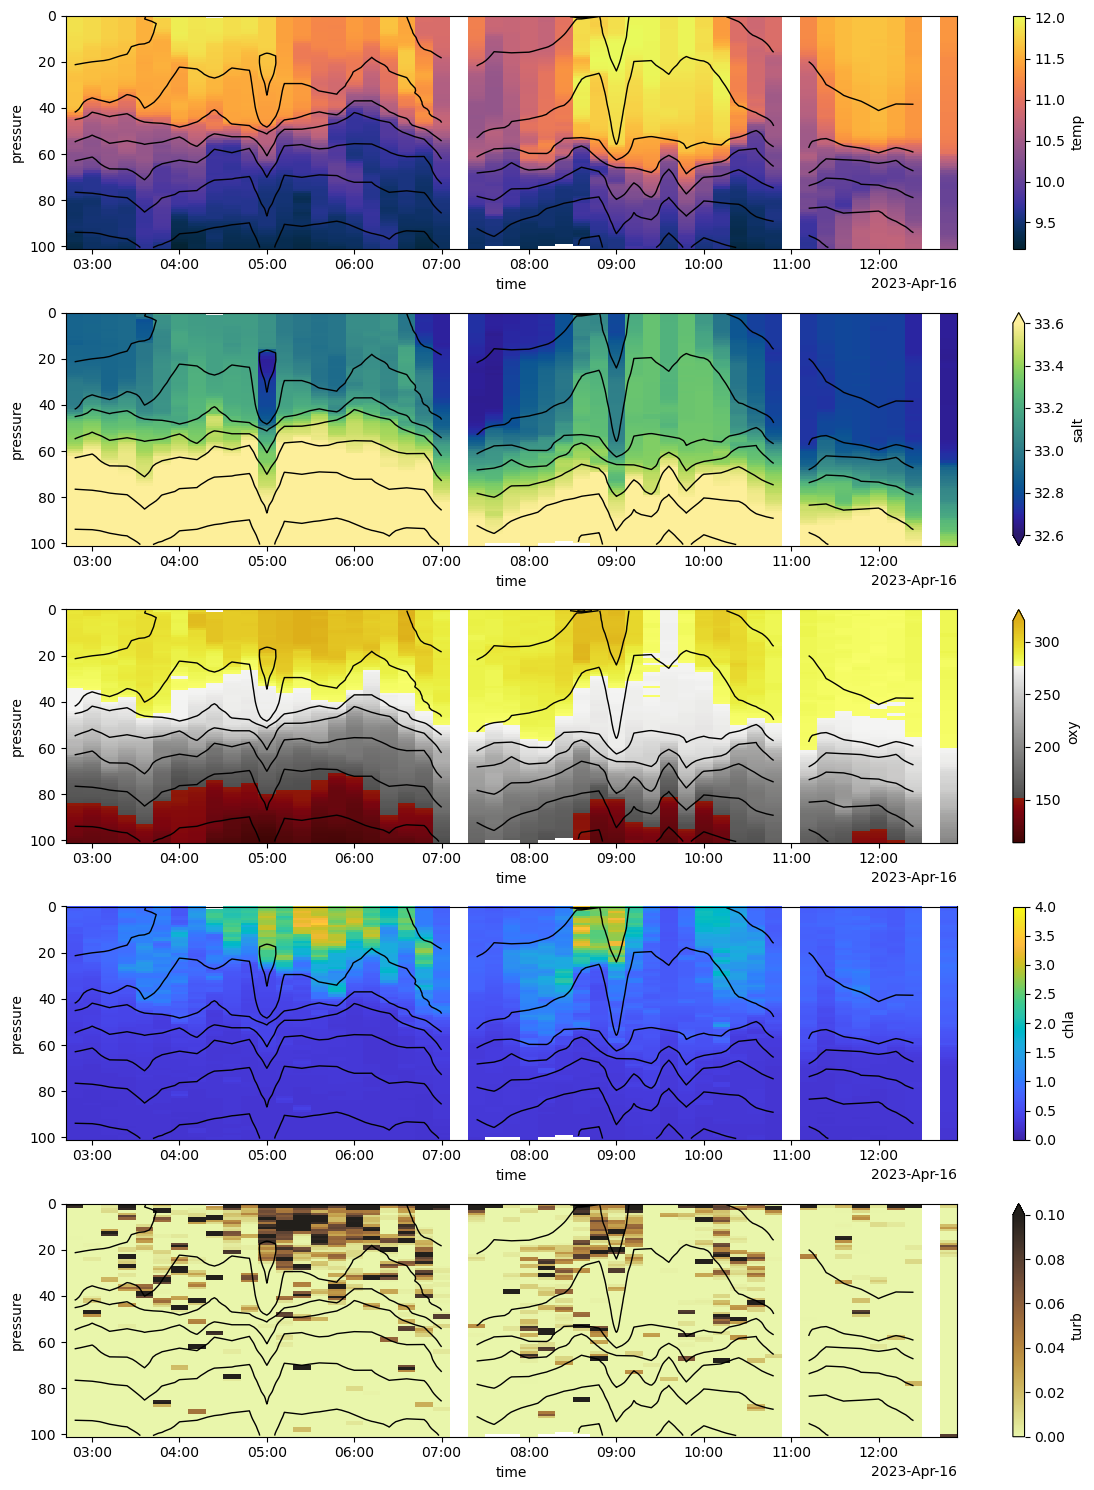

In [26]:
t1,t2='2023-04-18','2023-04-26T12'
t1,t2='2023-04-01T01','2023-04-16T12'
#t1,t2='2023-04-20T00','2023-04-20T11'
#t1,t2='2023-04-22T18','2023-04-23T00'
#t1,t2='2023-04-22T22:20','2023-04-23T00:10' # actual eddy only
#t1,t2 = '2023-04-22T21:20', '2023-04-22T23'

fig, ax = plt.subplots(5,1,figsize=(12,3*5))
#fig, ax = plt.subplots(5,1,figsize=(6,4*5))
da_ = da.sel(time=slice(t1,t2)).resample(time='0.2h').mean()

da_.temp.plot(ax=ax[0],cmap=cm.thermal,x='time')
da_.salt.plot(ax=ax[1],cmap=cm.haline,x='time',vmin=32.6,vmax=33.6)
da_.oxy.plot(ax=ax[2], cmap=cm.oxy,x='time',vmax=320)
da_.chla.plot(ax=ax[3],cmap=parula,x='time',vmin=0,vmax=4)
da_.turb.plot(ax=ax[4],cmap=cm.turbid,x='time',vmax=0.1)

# add density lines
for axis in ax:
    #axis.set_xticks(da_.time[::30],np.round(da_.lon[::30].values,2))
    #axis.set_xticks(da_.time[::2], labels=np.round(da_.lat.values, 2)[::2], rotation=45);
    axis.contour(da_.time,da_.pressure,da_.rho.T,10,colors='k',linewidths=1)
    axis.invert_yaxis()

plt.tight_layout()
plt.show();

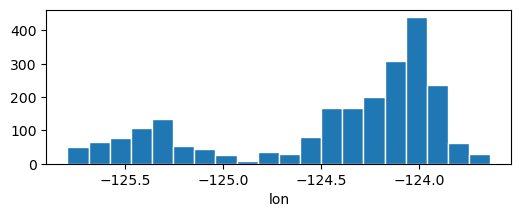

In [14]:
da.lon.plot.hist(bins=20,edgecolor='w',figsize=(6,2));

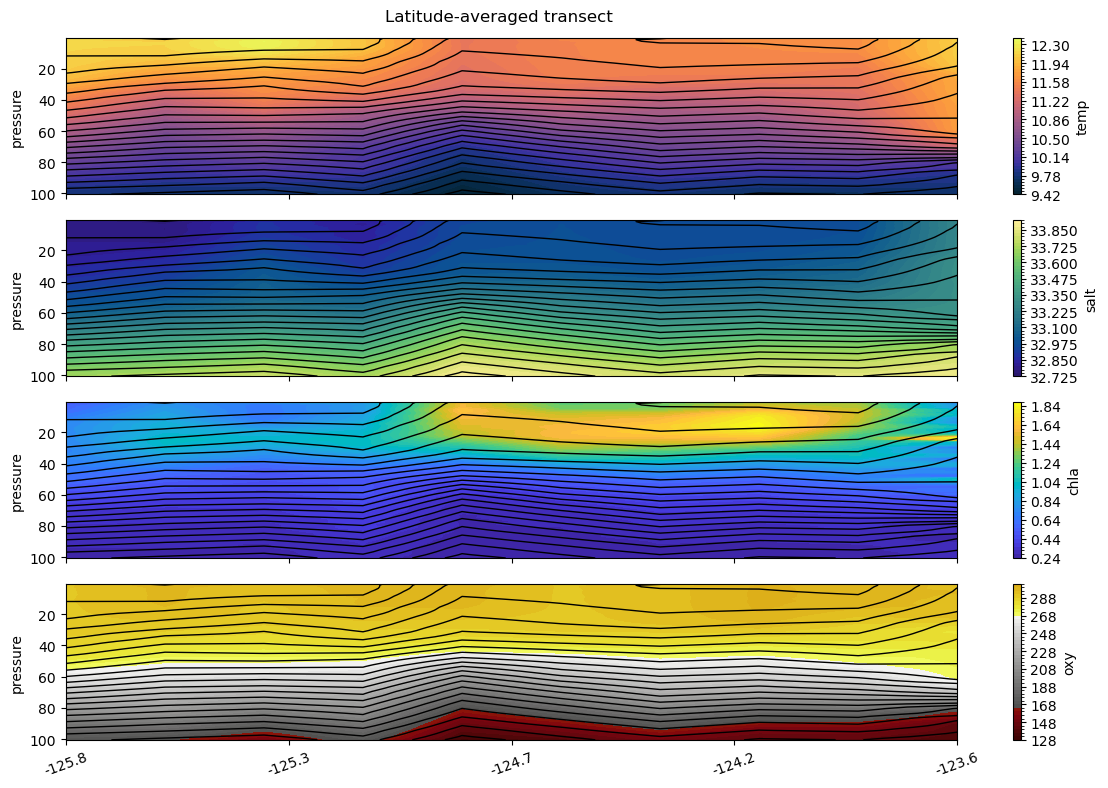

In [36]:
lon_bins = np.linspace(da['lon'].min(), da['lon'].max(),10)

da['lon_bin'] = lon_bins
da = da.set_coords('lon_bin')
da['lon_bin'] = xr.DataArray(np.digitize(da['lon'], lon_bins) - 1, dims='time')
da_grouped = da.groupby('lon_bin').mean()

fig,ax=plt.subplots(4,1,figsize=(12,8),sharex=True)
da_grouped.temp.plot.contourf(levels=50,x='lon_bin',cmap=cm.thermal,ax=ax[0])
da_grouped.salt.plot.contourf(levels=50,x='lon_bin',cmap=cm.haline,ax=ax[1])
da_grouped.chla.plot.contourf(levels=50,x='lon_bin',cmap=parula,ax=ax[2])
da_grouped.oxy.plot.contourf(levels=50,x='lon_bin',cmap=cm.oxy,ax=ax[3])

for axis in ax:
    da_grouped.rho.plot.contour(levels=30,x='lon_bin',colors='k',linewidths=1,ax=axis)
    axis.invert_yaxis()
    axis.set_xlabel('')
    
ax[-1].set_xticks(np.linspace(da.lon_bin.min(),da.lon_bin.max(),5), 
                    np.round(np.linspace(lon_bins[0],lon_bins[-1],5),1), rotation=20)
plt.suptitle('Latitude-averaged transect',x=0.42)
plt.tight_layout()
plt.show()

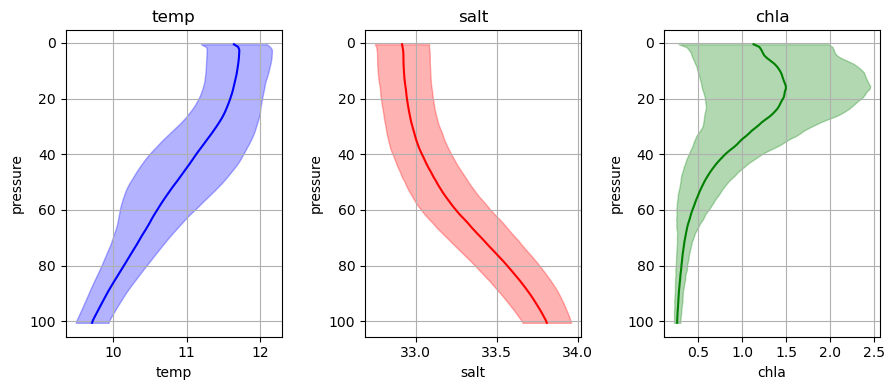

In [356]:
# vertical profiles
variables=['temp','salt','chla']
colors=['b','r','g']

fig, ax = plt.subplots(1,len(variables),figsize=(len(variables)*3,4))

for var,axis,color in zip(variables,ax,colors):
    mean=da[var].mean(dim='time')
    std = da[var].std(dim='time')

    mean.plot(y='pressure',color=color,ax=axis)
    axis.fill_betweenx(mean['pressure'], mean - std, mean + std, color=color, alpha=0.3)
    axis.invert_yaxis()
    axis.set_title(var)
    axis.grid()
plt.tight_layout()
plt.show();

In [ ]:
ls /Users/elise/data/SMODE-data/ShipBoardEcoCTD/

In [42]:
path = '/Users/elise/data/SMODE-data/'
ctd = xr.open_mfdataset(sorted(glob(path+'ShipBoardEcoCTD/S_MODE_IOP2_*.nc')))




ValueError: Failed to decode variable 'time': unable to decode time units 'days since 0000-01-01T00:00:00+00:00' with 'the default calendar'. Try opening your dataset with decode_times=False or installing cftime if it is not installed.